# Modélisation et Évaluation du Risque de Diabète

L'objectif de ce notebook est d'entraîner, évaluer et comparer deux algorithmes de Machine Learning sur nos données nettoyées et standardisées :
1. **Régression Logistique (Baseline) :** C'est un modèle linéaire simple et directement interprétable via ses coefficients.
2. **Forêt Aléatoire (Random Forest) :** Ce modèle ensembliste non-linéaire, basé sur un ensemble d'arbres de décision, est plus complexe et capable d'établir des relations complexes entre nos variables.

## Pourquoi le Recall (Sensibilité) est notre priorité dans ce contexte clinique ?

Dans un contexte médical de dépistage du diabète, il y a plusieurs paramètres à prendre en compte :
- **Faux Négatif (FN) :** Le modèle pourrait prédire qu'un patient est sain alors qu'il est diabétique. Le patient ne reçoit donc pas de traitement ni de suivi, ce qui peut avoir de graves complications à long terme. **C'est une erreur très dangereuse.**
- **Faux Positif (FP) :** Le modèle pourrait prédire un risque de diabète pour un patient sain. Le patient fera des examens sanguins complémentaires qui infirmeront le diagnostic. C'est une situation gênante pour le patient (stress, coût d'examen), mais ce n'est pas mortel.

Par conséquent, nous chercherons avant tout à maximiser le **Recall (Sensibilité)**, qui mesure notre capacité à détecter tous les patients malades sans en rater.

In [20]:
import sys
import shap
sys.path.append('..')  # Pour pouvoir importer depuis src/

import joblib
import os

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from src.train import train_logistic_regression, train_random_forest, evaluate_model

In [5]:
# Chargement des données d'entraînement et de test
X_train = pd.read_csv("../data/processed/X_train_clean.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv("../data/processed/X_test_clean.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Dimensions Train : X={X_train.shape}, y={y_train.shape}")
print(f"Dimensions Test  : X={X_test.shape}, y={y_test.shape}")

Dimensions Train : X=(614, 8), y=(614,)
Dimensions Test  : X=(154, 8), y=(154,)


## 1. Modèle Baseline : Régression Logistique

Nous commençons par entraîner une Régression Logistique. C'est notre point de comparaison minimum à battre (Baseline). En médecine, sa popularité s'explique parce qu'on peut examiner ses **coefficients** : chaque pondération nous montre l'impact d'une variable sur la probabilité de développer un diabète.

In [6]:
# 1. Entraînement sur le jeu d'entraînement
lr_model = train_logistic_regression(X_train, y_train)

# 2. Évaluation sur le jeu de test secret
lr_scores = evaluate_model(lr_model, X_test, y_test)

# 3. Affichage des résultats sous forme de tableau Pandas propre
print("Résultats de la Régression Logistique (Baseline) :")
pd.DataFrame([lr_scores], index=["Logistic Regression"]).round(4)

Résultats de la Régression Logistique (Baseline) :


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7078,0.6,0.5,0.5455,0.813


In [7]:
# Extraction des coefficients et création d'un tableau trié
coefs = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)

print("Importance des variables selon la Régression Logistique :")
display(coefs)

Importance des variables selon la Régression Logistique :


,Feature,Coefficient
1,Glucose,1.182567
5,BMI,0.688652
0,Pregnancies,0.377446
6,DiabetesPedigreeFunction,0.233337
7,Age,0.147794
3,SkinThickness,0.028321
2,BloodPressure,-0.044111
4,Insulin,-0.066119


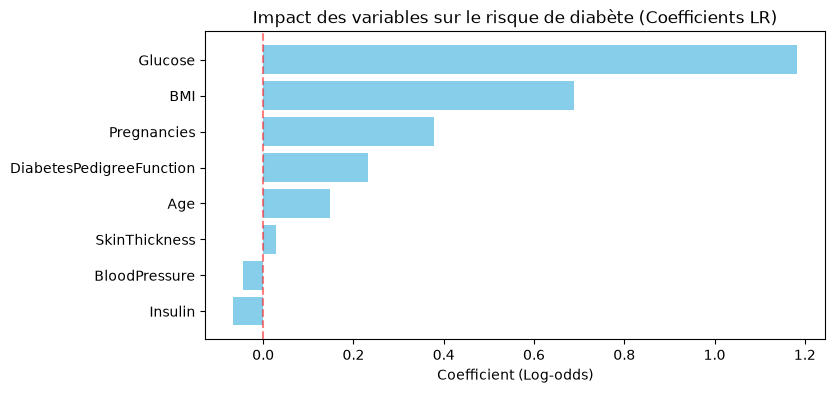

In [8]:
# Histograme pour facilité la lisibilité 
plt.figure(figsize=(8, 4))
plt.barh(coefs['Feature'], coefs['Coefficient'], color='skyblue')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title("Impact des variables sur le risque de diabète (Coefficients LR)")
plt.xlabel("Coefficient (Log-odds)")
plt.gca().invert_yaxis() # Pour mettre la plus importante en haut
plt.show()

## 2. Modèle Avancé : Forêt Aléatoire (Random Forest)

La Forêt Aléatoire est un algorithme ensembliste qui combine le vote de plusieurs centaines d'arbres de décision. Contrairement à la Régression Logistique qui trace une simple frontière linéaire, la Forêt Aléatoire peut capturer :
- Des seuils non-linéaires (ex: le risque explose uniquement au-delà d'un certain seuil exact de Glucose).
- Des interactions fortes entre variables (ex: un IMC moyen est plus dangereux chez un patient âgé que chez un patient jeune).

In [9]:
# 1. Entraînement de la Forêt Aléatoire
rf_model = train_random_forest(X_train, y_train)

# 2. Évaluation sur le jeu de test
rf_scores = evaluate_model(rf_model, X_test, y_test)

# 3. Tableau comparatif final !
comparison_df = pd.DataFrame([lr_scores, rf_scores], index=["Logistic Regression (Baseline)", "Random Forest"]).round(4)

print("Tableau Comparatif des Performances :")
display(comparison_df)

Tableau Comparatif des Performances :


,accuracy,precision,recall,f1,roc_auc
Logistic Regression (Baseline),0.7078,0.6000,0.5000,0.5455,0.8130
Random Forest,0.7727,0.7021,0.6111,0.6535,0.8181


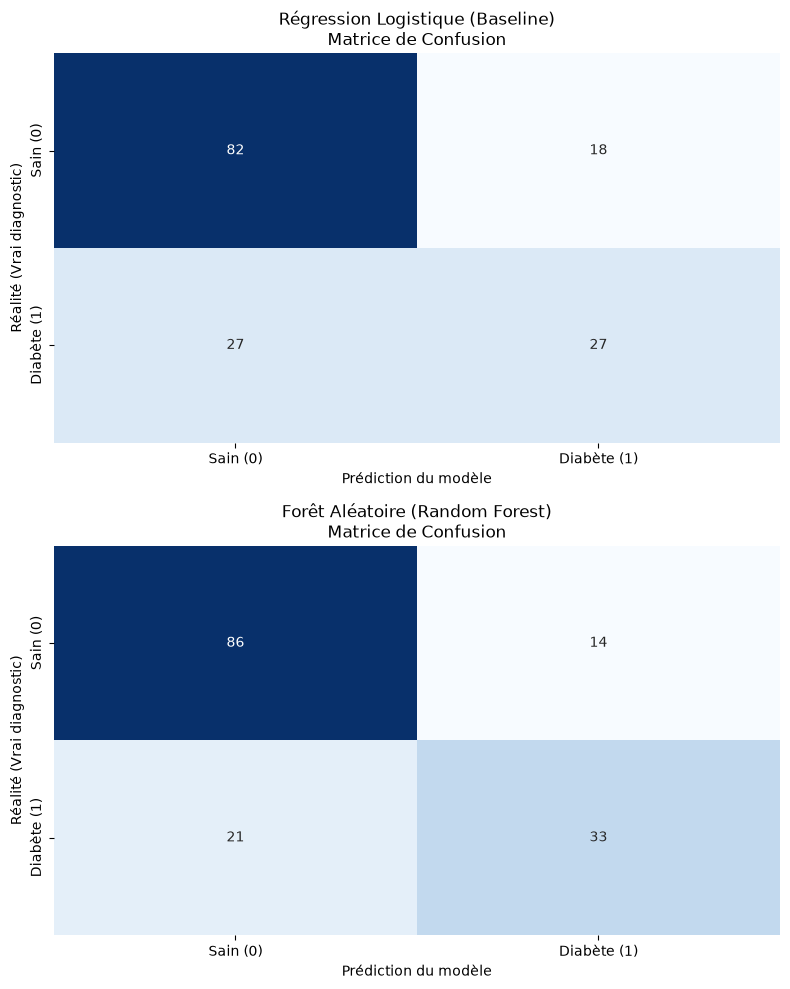

In [14]:
# Calcul des prédictions sur le test pour les deux modèles
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Calcul des matrices de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Affichage côte à côte
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Sain (0)', 'Diabète (1)'], yticklabels=['Sain (0)', 'Diabète (1)'])
axes[0].set_title('Régression Logistique (Baseline)\nMatrice de Confusion')
axes[0].set_ylabel('Réalité (Vrai diagnostic)')
axes[0].set_xlabel('Prédiction du modèle')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Sain (0)', 'Diabète (1)'], yticklabels=['Sain (0)', 'Diabète (1)'])
axes[1].set_title('Forêt Aléatoire (Random Forest)\nMatrice de Confusion')
axes[1].set_ylabel('Réalité (Vrai diagnostic)')
axes[1].set_xlabel('Prédiction du modèle')

plt.tight_layout()
plt.show()

## 3. Interprétabilité du modèle complexe avec SHAP (SHapley Additive exPlanations)

Bien que la Forêt Aléatoire surpasse la Régression Logistique en Recall (+4 patients sauvés), sa nature d'ensemble de 100 arbres de décision en fait une "boîte noire". Pour une application médicale réelle, la confiance des médecins et l'explicabilité de chaque décision sont indispensables.

Nous utilisons **SHAP**, une méthode issue de la théorie des jeux qui calcule l'apport exact de chaque variable clinique sur la probabilité finale prédite par le modèle.

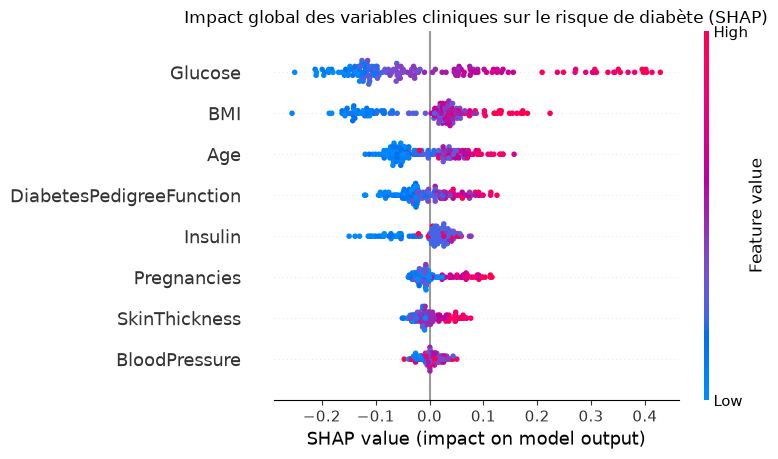

In [18]:
# 1. Initialisation de l'explicateur SHAP spécialisé pour les arbres
explainer = shap.TreeExplainer(rf_model)

# 2. Calcul des valeurs SHAP sur l'ensemble de test
shap_values = explainer.shap_values(X_test)

# Extraction des explications pour la classe 1 (Risque de Diabète)
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

# 3. Affichage du Summary Plot (Beeswarm)
plt.figure(figsize=(10, 6))
plt.title("Impact global des variables cliniques sur le risque de diabète (SHAP)")
shap.summary_plot(shap_vals_class1, X_test, feature_names=X_test.columns, show=True)

In [21]:
# Création du dossier models/ s'il n'existe pas encore
os.makedirs("../models", exist_ok=True)

# Sauvegarde de notre Forêt Aléatoire et de notre Régression Logistique
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

print("Modèles sauvegardés avec succès dans le dossier models/ :")
print("  - models/random_forest_model.pkl")
print("  - models/logistic_regression_model.pkl")

Modèles sauvegardés avec succès dans le dossier models/ :
  - models/random_forest_model.pkl
  - models/logistic_regression_model.pkl
